# Cardiovascular Disease Prediction Using Tree-Based Ensemble Models

Companion code for *Cardiovascular Disease Detection using a Multi-model Pipeline*.

The dataset is the [Cardiovascular Disease dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)
(Sulianova, Kaggle, 2019): 70,000 patient records with 11 attributes and a binary target.
Place `cardio_train.csv` beside this notebook and run *Restart and run all* to reproduce
every table and figure in the paper.

## 1. Setup

Imports and the shared plotting style. Each figure is written to `figures/` on an identical
1280x960 canvas and saved as its own file.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve,
                             average_precision_score)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

FIGSIZE, DPI, OUT = (6.4, 4.8), 200, 'figures'
os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({
    'figure.figsize': FIGSIZE, 'figure.dpi': DPI, 'savefig.dpi': DPI,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True,
    'figure.constrained_layout.use': True,
})

PALETTE = {'LightGBM': '#7B52AB', 'XGBoost': '#1F6FB2',
           'Gradient Boosting': '#D2691E', 'Random Forest': '#2E8B57'}
CMAPS = {'LightGBM': 'Purples', 'XGBoost': 'Blues',
         'Gradient Boosting': 'Oranges', 'Random Forest': 'Greens'}

def save(fig, name):
    fig.set_size_inches(*FIGSIZE)
    fig.savefig(f'{OUT}/{name}.png', dpi=DPI)
    plt.show()

## 2. Loading the data

The file is semicolon separated. This cell reports the shape and confirms the missing-value count.

In [2]:
df = pd.read_csv('cardio_train.csv', sep=';')
print(f'Dataset shape  : {df.shape}')
print(f'Missing values : {int(df.isnull().sum().sum())}')
df.head()

Dataset shape  : (70000, 13)
Missing values : 0


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.describe().round(2)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


## 3. Exploratory data analysis

Class balance and the relationship between age and the target, inspected on the raw data.

### 3.1 Target class distribution

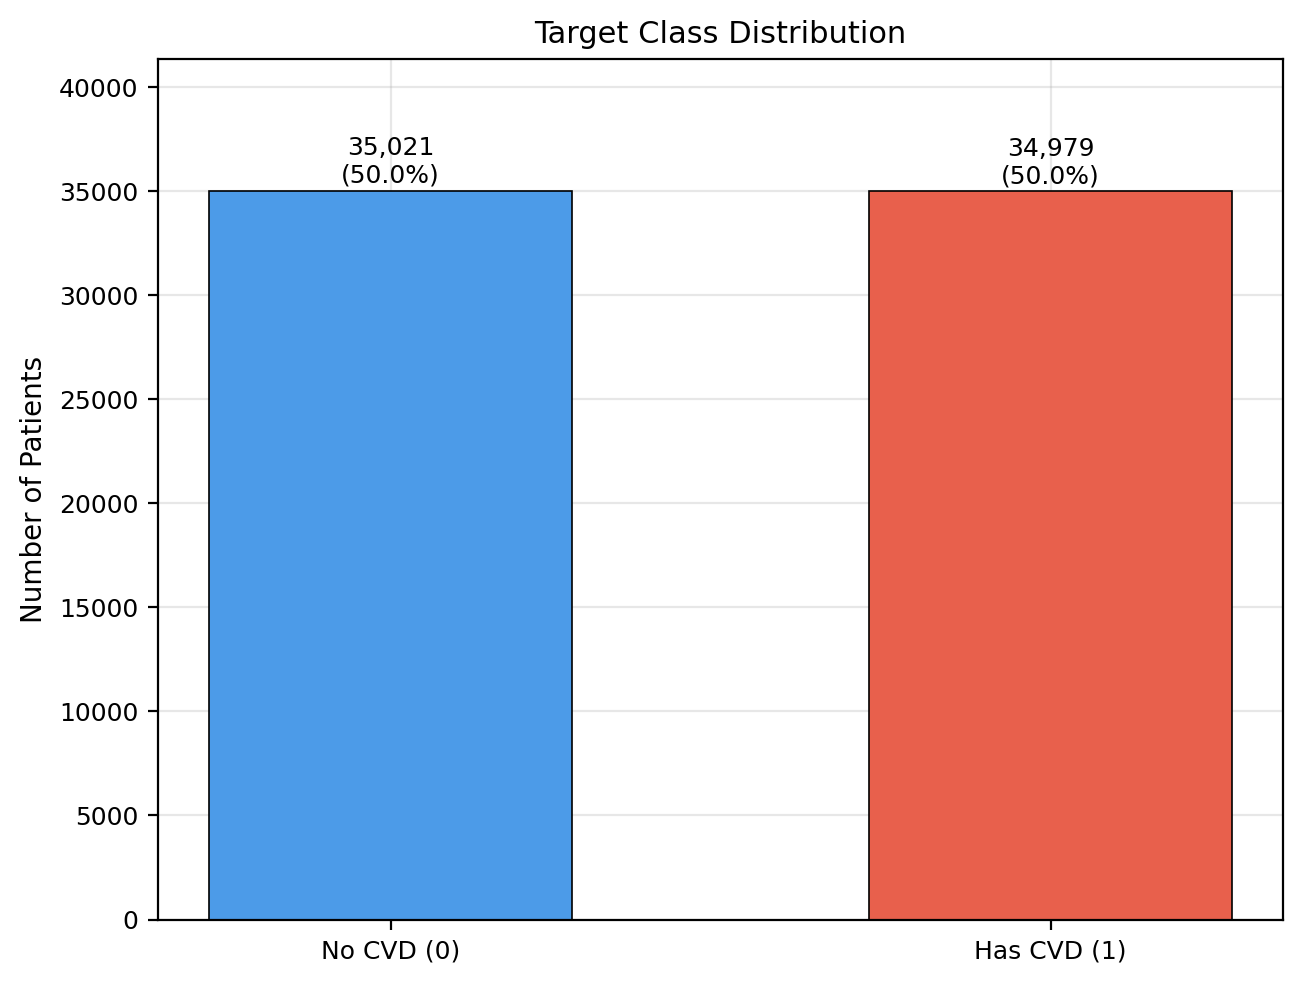

In [4]:
fig, ax = plt.subplots()
vc = df['cardio'].value_counts().sort_index()
bars = ax.bar(['No CVD (0)', 'Has CVD (1)'], vc.values, width=0.55,
              color=['#4C9BE8', '#E8604C'], edgecolor='black', linewidth=0.6)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 400,
            f'{v:,}\n({v / len(df) * 100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, vc.max() * 1.18)
ax.set_title('Target Class Distribution')
save(fig, 'fig_class_distribution')

### 3.2 Class balance

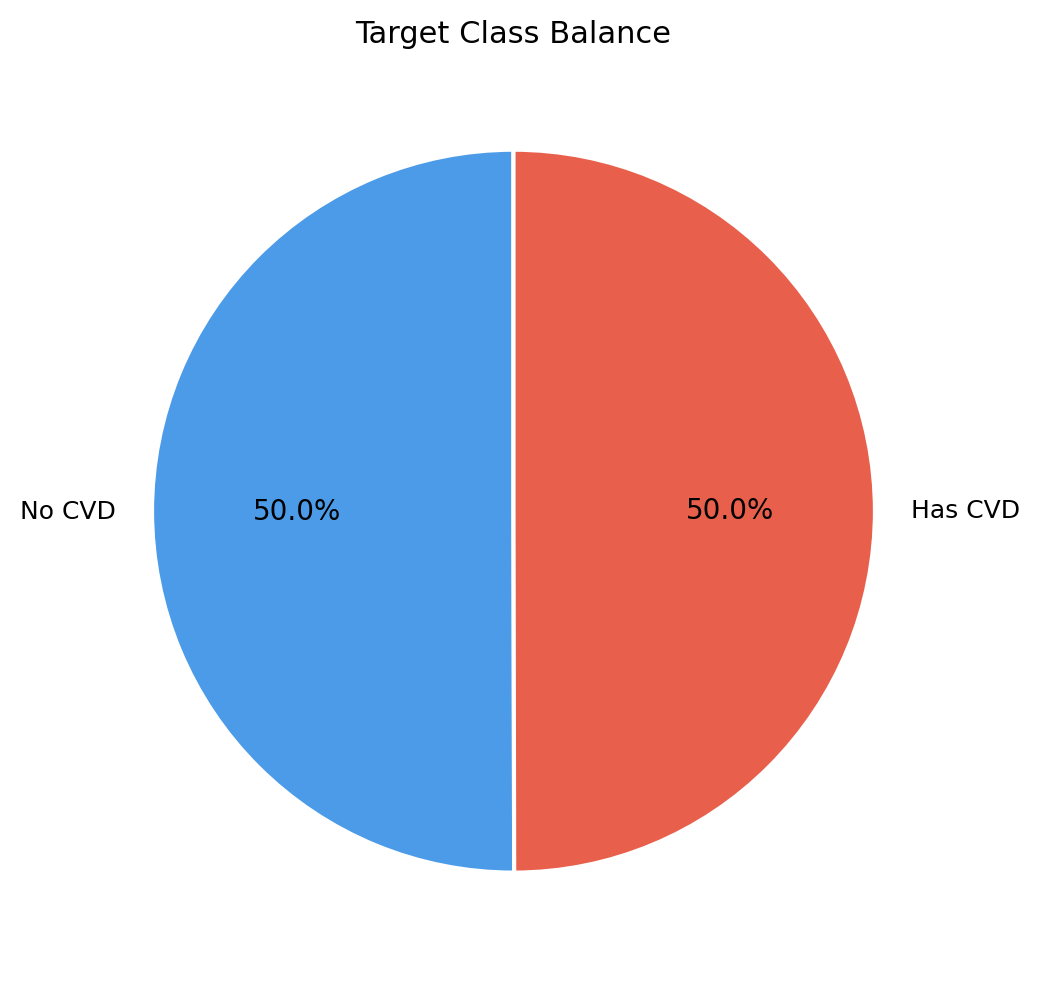

In [5]:
fig, ax = plt.subplots()
ax.pie(vc.values, labels=['No CVD', 'Has CVD'], autopct='%1.1f%%',
       colors=['#4C9BE8', '#E8604C'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Target Class Balance')
ax.grid(False)
save(fig, 'fig_class_balance')

### 3.3 Age distribution by CVD status

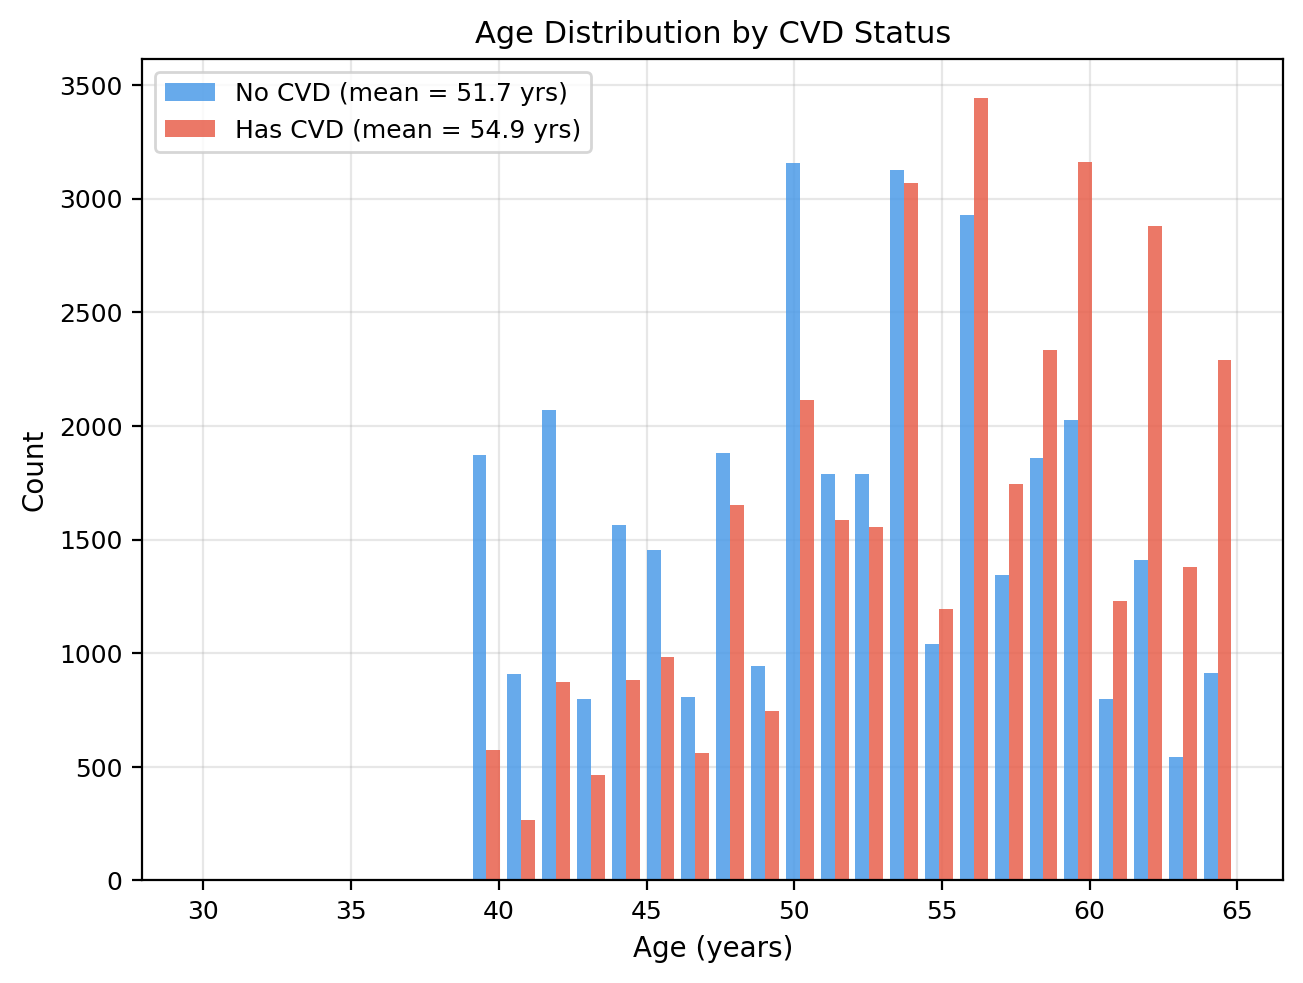

In [6]:
age_y = df['age'] / 365.25
fig, ax = plt.subplots()
ax.hist([age_y[df.cardio == 0], age_y[df.cardio == 1]], bins=30,
        color=['#4C9BE8', '#E8604C'], alpha=0.85,
        label=[f'No CVD (mean = {age_y[df.cardio == 0].mean():.1f} yrs)',
               f'Has CVD (mean = {age_y[df.cardio == 1].mean():.1f} yrs)'])
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Age Distribution by CVD Status')
save(fig, 'fig_age_distribution')

### 3.4 Age spread by CVD status

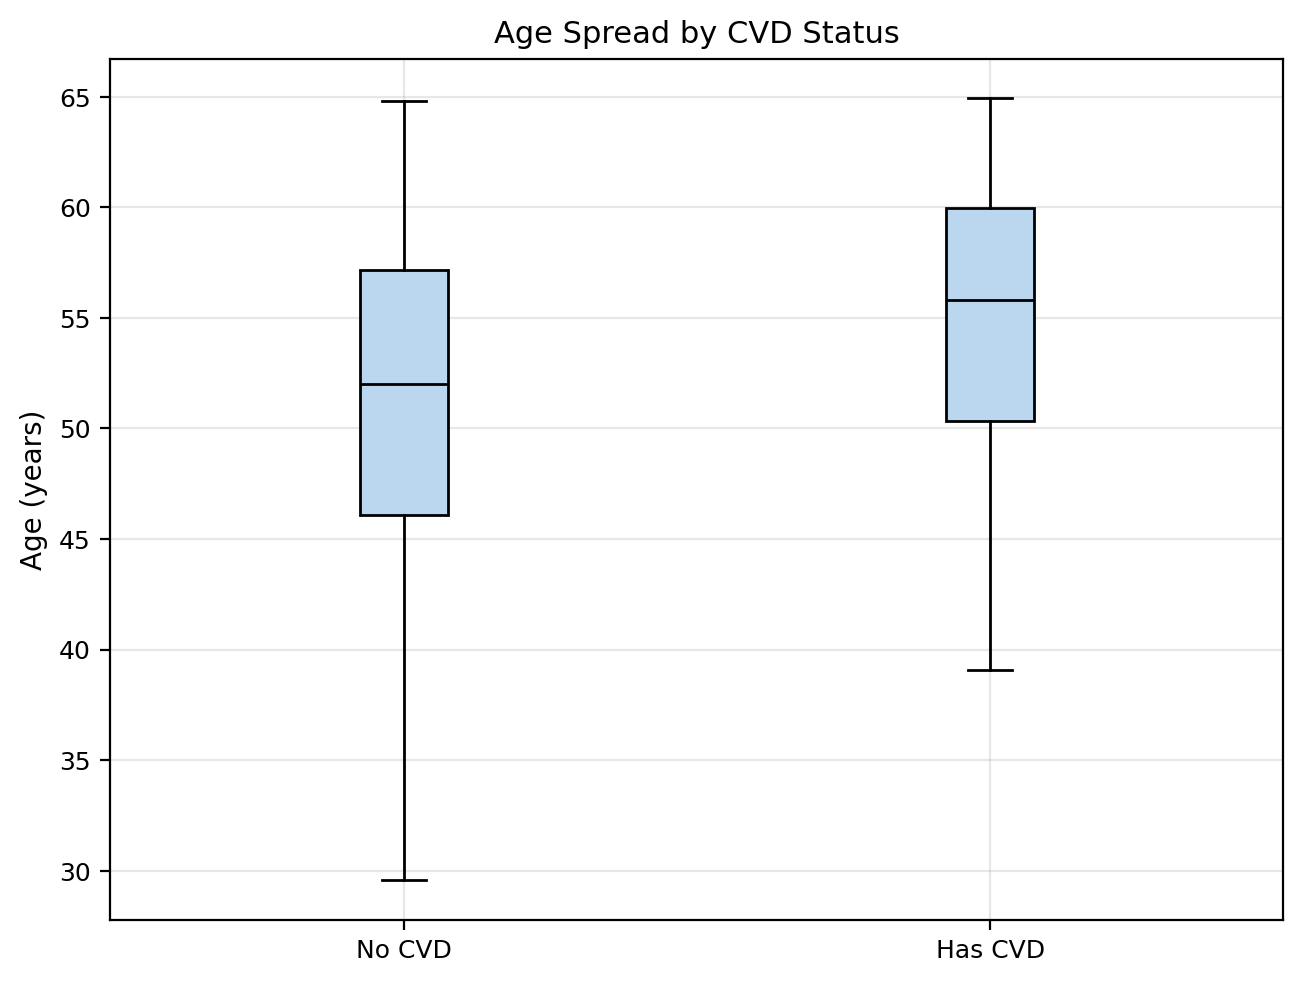

In [7]:
fig, ax = plt.subplots()
ax.boxplot([age_y[df.cardio == 0], age_y[df.cardio == 1]],
           labels=['No CVD', 'Has CVD'], patch_artist=True,
           boxprops={'facecolor': '#BBD7F0', 'edgecolor': 'black'},
           medianprops={'color': 'black'})
ax.set_ylabel('Age (years)')
ax.set_title('Age Spread by CVD Status')
save(fig, 'fig_age_boxplot')

## 4. Data cleaning

The row identifier carries no predictive information and is dropped. Exact duplicate rows are
then removed.

In [8]:
print(f'Shape before   : {df.shape}')
df = df.drop(columns=['id'])
n_dup = int(df.duplicated().sum())
df = df.drop_duplicates()
print(f'Duplicates     : {n_dup}')
print(f'Shape after    : {df.shape}')

Shape before   : (70000, 13)
Duplicates     : 24
Shape after    : (69976, 12)


### 4.1 Physiological range check

Counts of values that fall outside plausible clinical ranges. These are reported for reference;
they are corrected by the clipping step in Section 6 rather than deleted.

In [9]:
checks = {
    'Systolic BP < 50 or > 250 mmHg':   df[(df.ap_hi < 50) | (df.ap_hi > 250)],
    'Diastolic BP < 30 or > 150 mmHg':  df[(df.ap_lo < 30) | (df.ap_lo > 150)],
    'Systolic <= diastolic (inverted)': df[df.ap_hi <= df.ap_lo],
    'Height < 100 or > 220 cm':         df[(df.height < 100) | (df.height > 220)],
    'Weight < 30 or > 200 kg':          df[(df.weight < 30) | (df.weight > 200)],
}
for desc, subset in checks.items():
    print(f'{desc:<36} {len(subset):>5} records')

Systolic BP < 50 or > 250 mmHg         228 records
Diastolic BP < 30 or > 150 mmHg       1028 records
Systolic <= diastolic (inverted)      1236 records
Height < 100 or > 220 cm                30 records
Weight < 30 or > 200 kg                  7 records


### 4.2 Distributions before clipping

Each of the four most affected features is plotted separately.

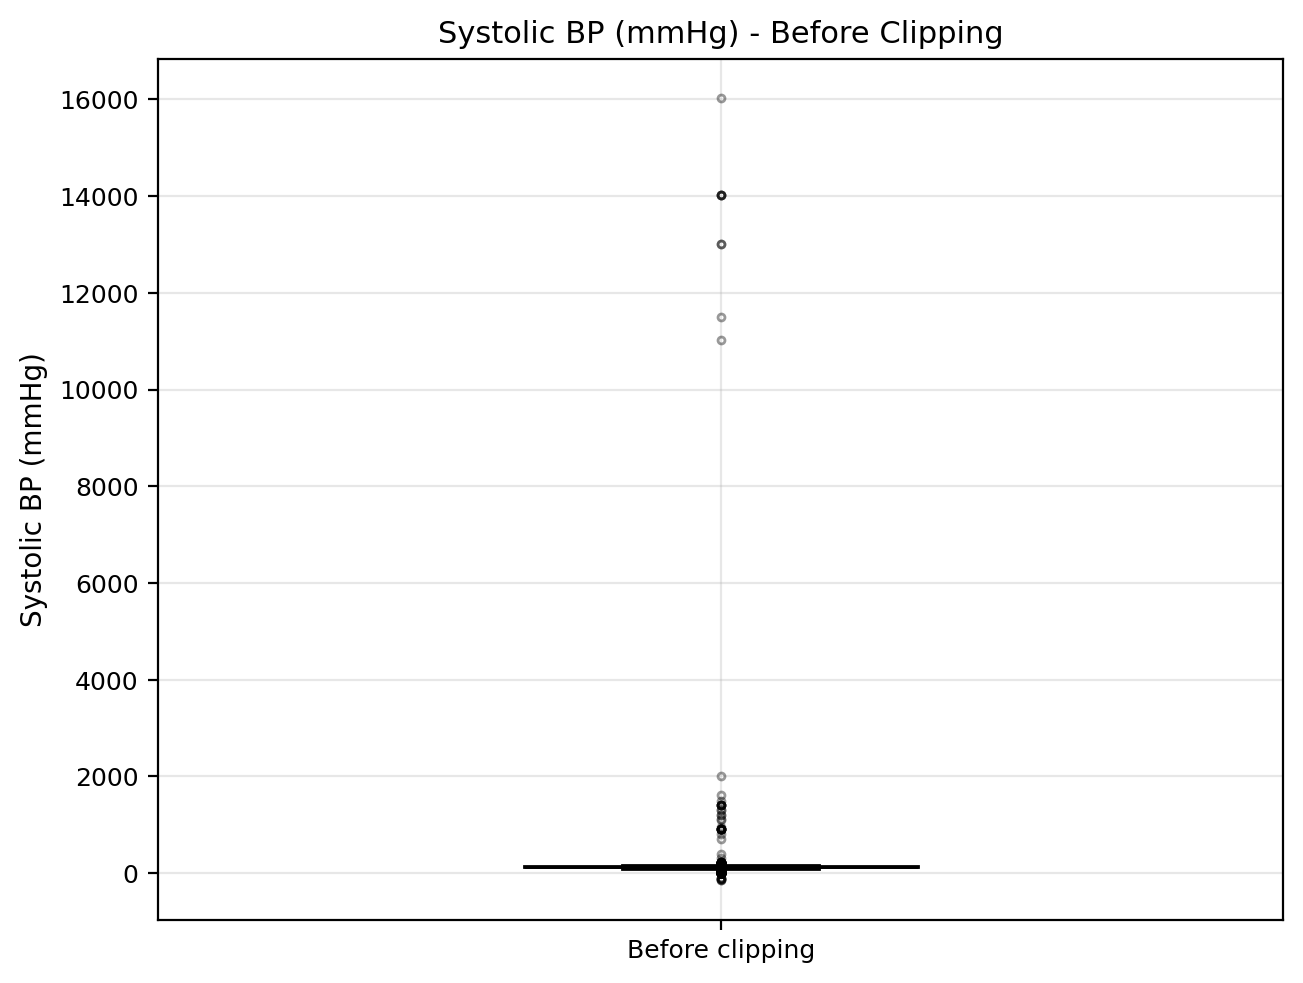

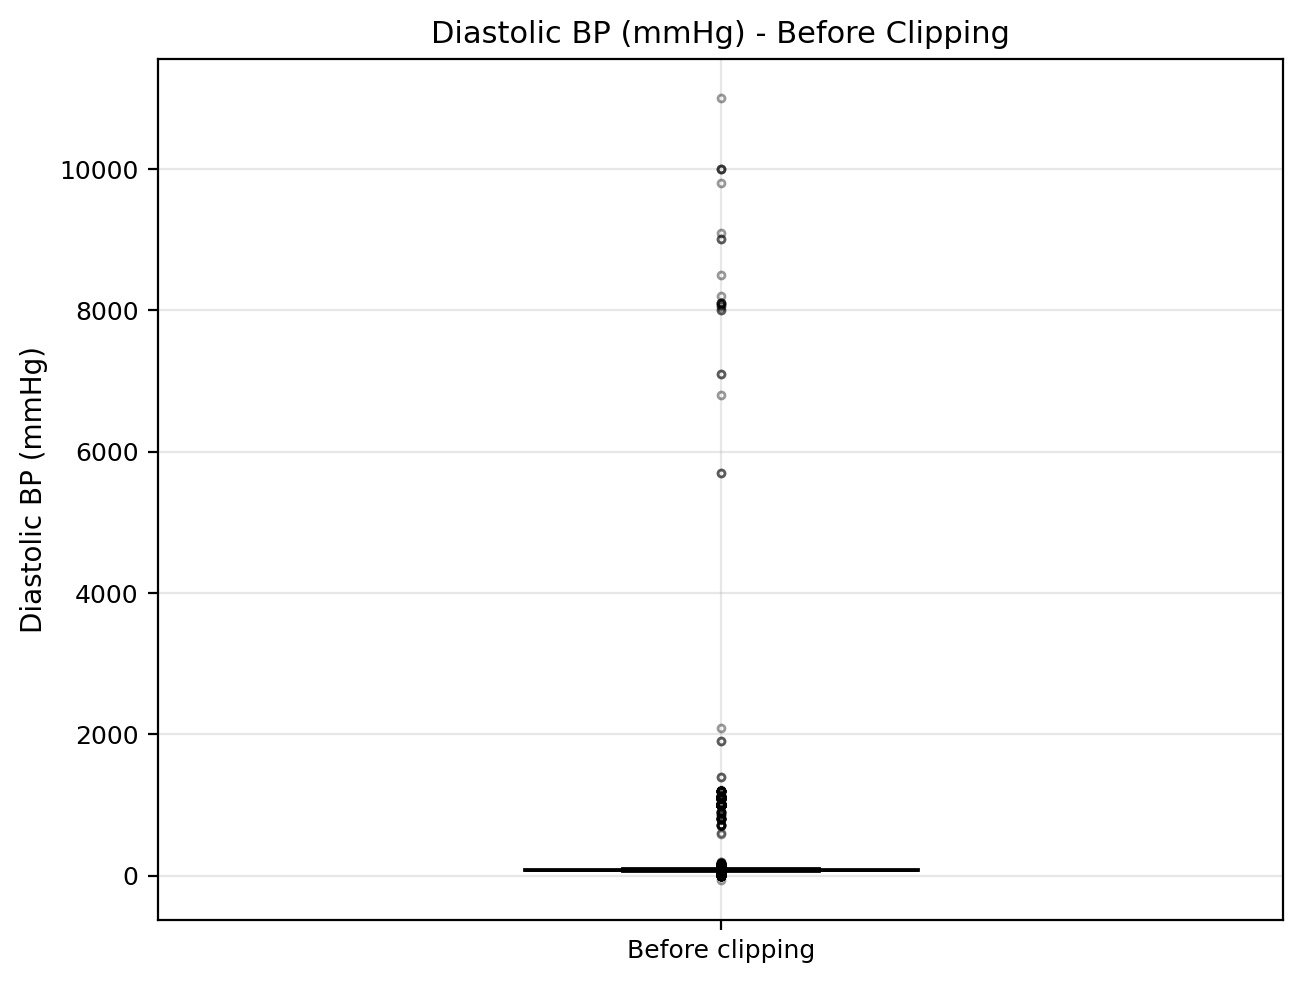

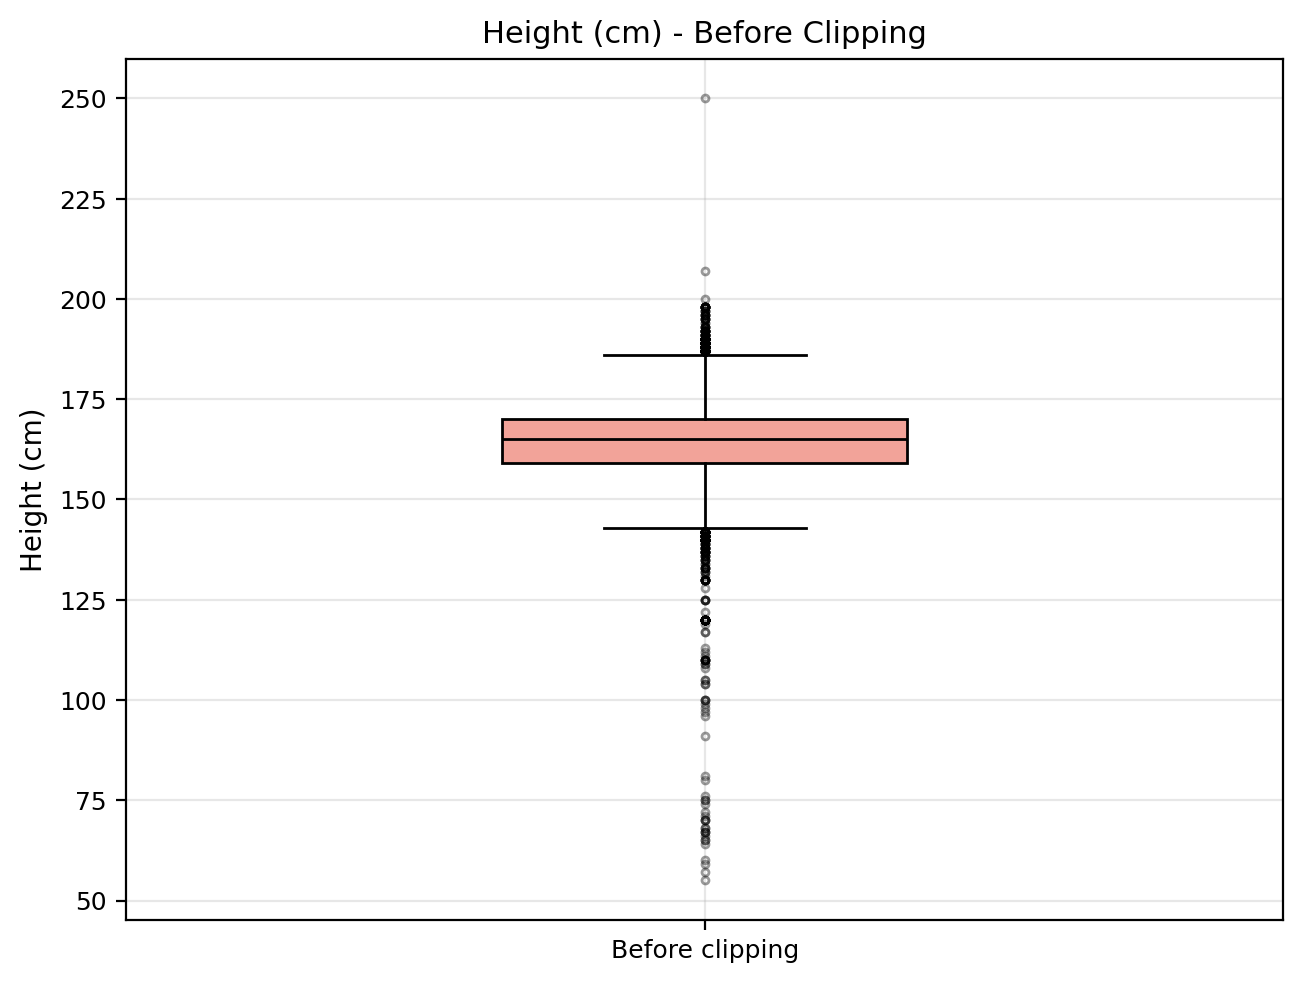

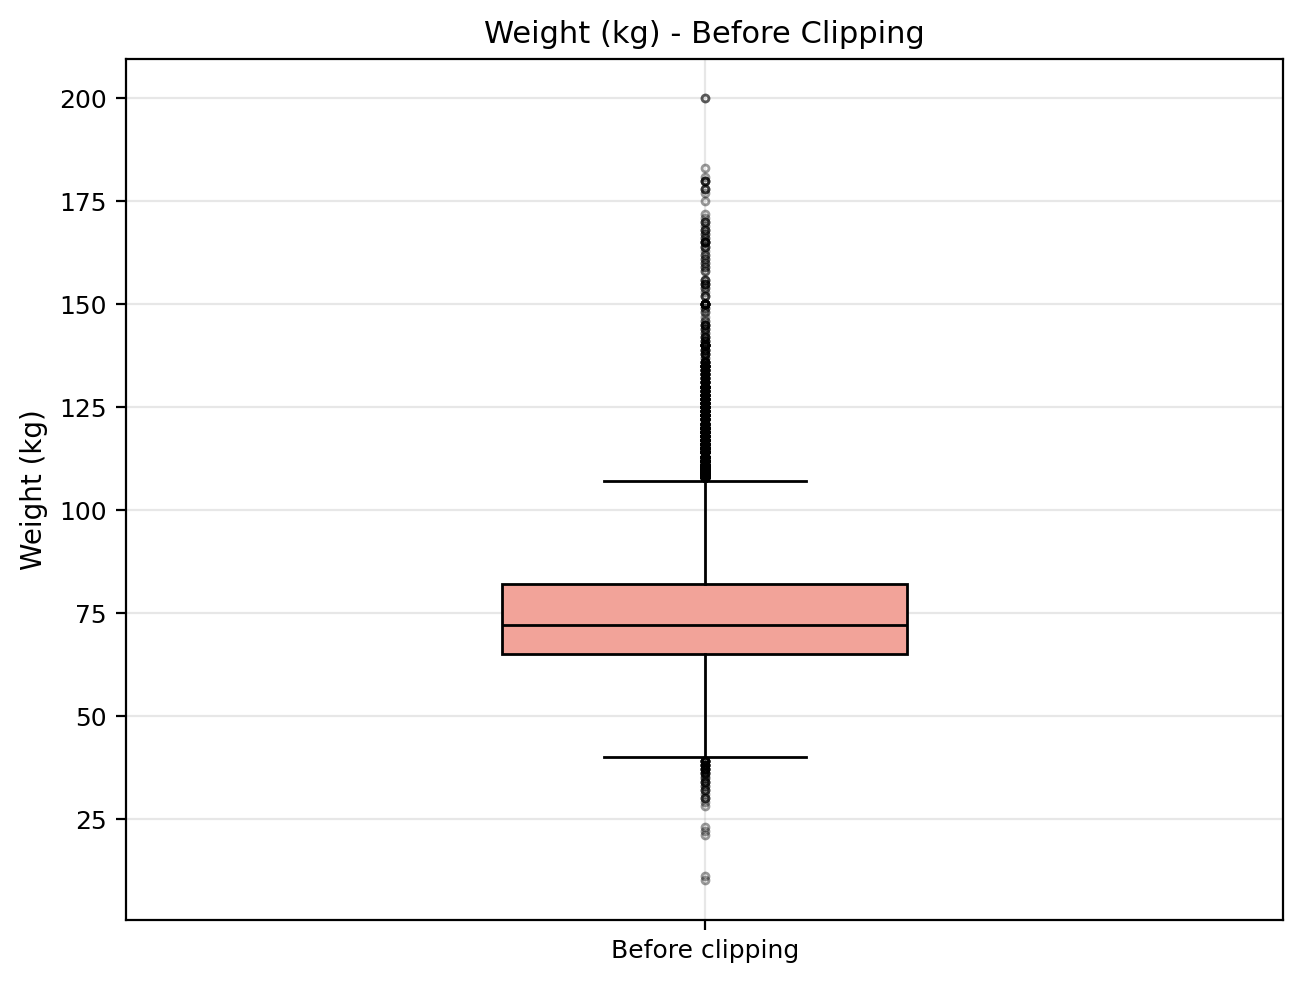

In [10]:
LABELS = {'ap_hi': 'Systolic BP (mmHg)', 'ap_lo': 'Diastolic BP (mmHg)',
          'height': 'Height (cm)', 'weight': 'Weight (kg)'}

for col, lab in LABELS.items():
    fig, ax = plt.subplots()
    ax.boxplot(df[col], patch_artist=True, widths=0.35,
               boxprops={'facecolor': '#F2A399', 'edgecolor': 'black'},
               medianprops={'color': 'black'},
               flierprops={'markersize': 2.5, 'alpha': 0.4})
    ax.set_ylabel(lab)
    ax.set_xticks([1]); ax.set_xticklabels(['Before clipping'])
    ax.set_title(f'{lab} - Before Clipping')
    save(fig, f'fig_box_before_{col}')

## 5. Feature encoding

Age is converted from days to years, height from centimetres to metres, and gender is recoded
to a 0/1 scale.

In [11]:
df['age_years'] = df['age'] / 365.25
df['gender']    = df['gender'] - 1
df['height']    = df['height'] / 100
df = df.drop(columns=['age'])
print(f'Columns: {list(df.columns)}')

Columns: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


## 6. Split, clipping and scaling

The data is split 80/20 with stratification on the target. IQR bounds and the scaler are both
computed on the training partition and then applied to both partitions.

In [12]:
y = df['cardio']
X = df.drop(columns=['cardio'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_test = X_train.copy(), X_test.copy()

print(f'Training set : {len(X_train):,}')
print(f'Test set     : {len(X_test):,}  '
      f'(No CVD = {int((y_test == 0).sum()):,}, Has CVD = {int((y_test == 1).sum()):,})')

Training set : 55,980
Test set     : 13,996  (No CVD = 7,001, Has CVD = 6,995)


### 6.1 IQR clipping

Values below `Q1 - 1.5 x IQR` are raised to that bound and values above `Q3 + 1.5 x IQR` are
reduced to it. Every record is retained.

In [13]:
CLIP = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
bounds = {}
for c in CLIP:
    q1, q3 = X_train[c].quantile(0.25), X_train[c].quantile(0.75)
    iqr = q3 - q1
    bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    X_train[c] = X_train[c].clip(*bounds[c])
    X_test[c]  = X_test[c].clip(*bounds[c])

for c, (lo, hi) in bounds.items():
    print(f'{c:<12} [{lo:.2f}, {hi:.2f}]')

height       [1.43, 1.86]
weight       [39.50, 107.50]
ap_hi        [90.00, 170.00]
ap_lo        [65.00, 105.00]
age_years    [33.40, 73.40]


### 6.2 Engineered features

Body mass index and pulse pressure are derived from the clipped measurements, giving 13 features.

In [14]:
for d in (X_train, X_test):
    d['bmi']            = d['weight'] / (d['height'] ** 2)
    d['pulse_pressure'] = d['ap_hi'] - d['ap_lo']

FEATURES = list(X_train.columns)
print(f'Final feature set ({len(FEATURES)}): {FEATURES}')

Final feature set (13): ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure']


### 6.3 Distributions after clipping

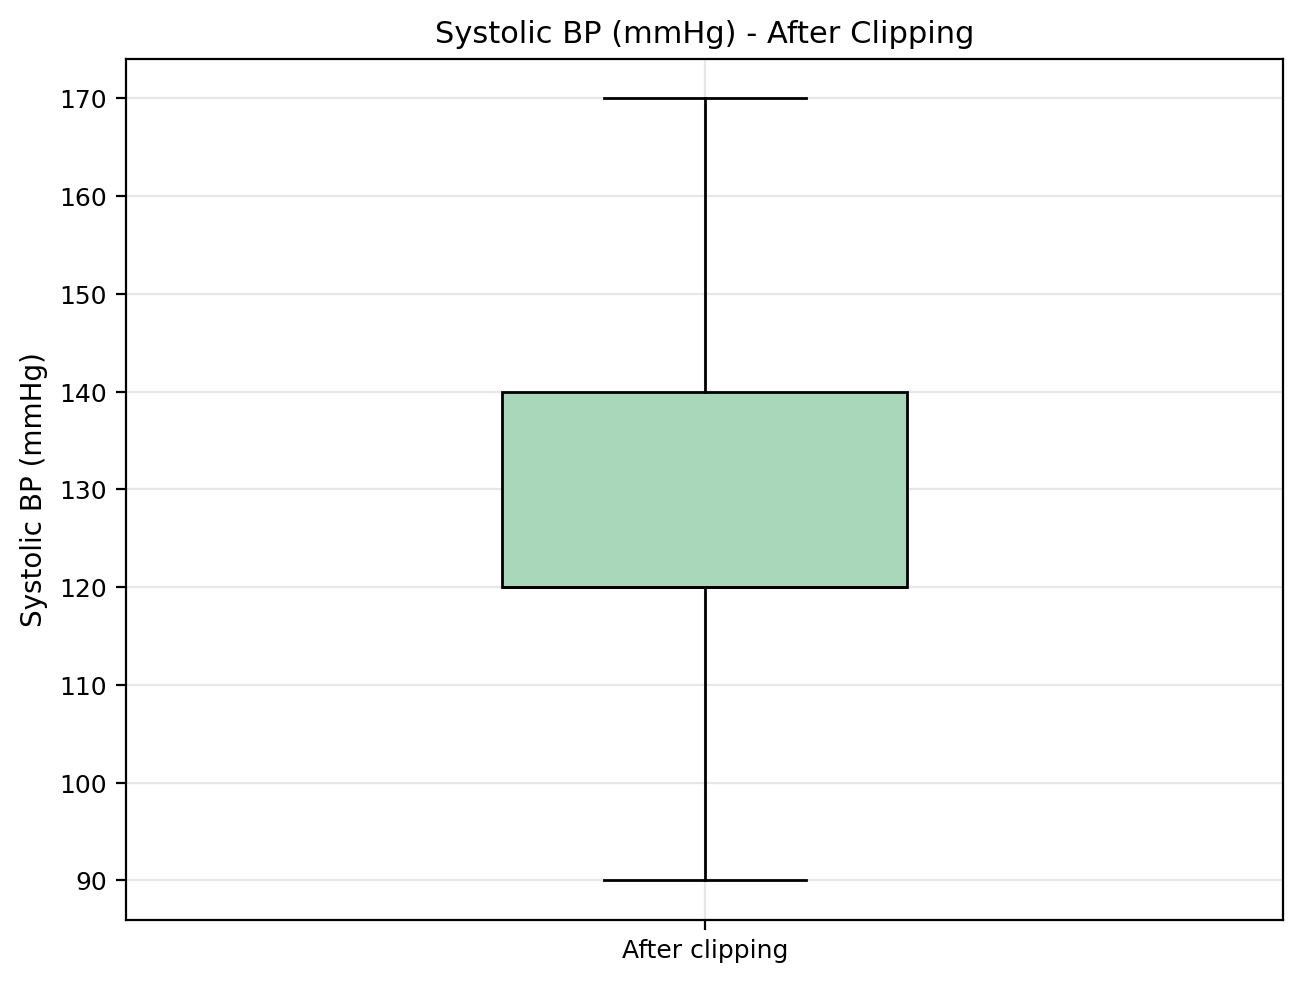

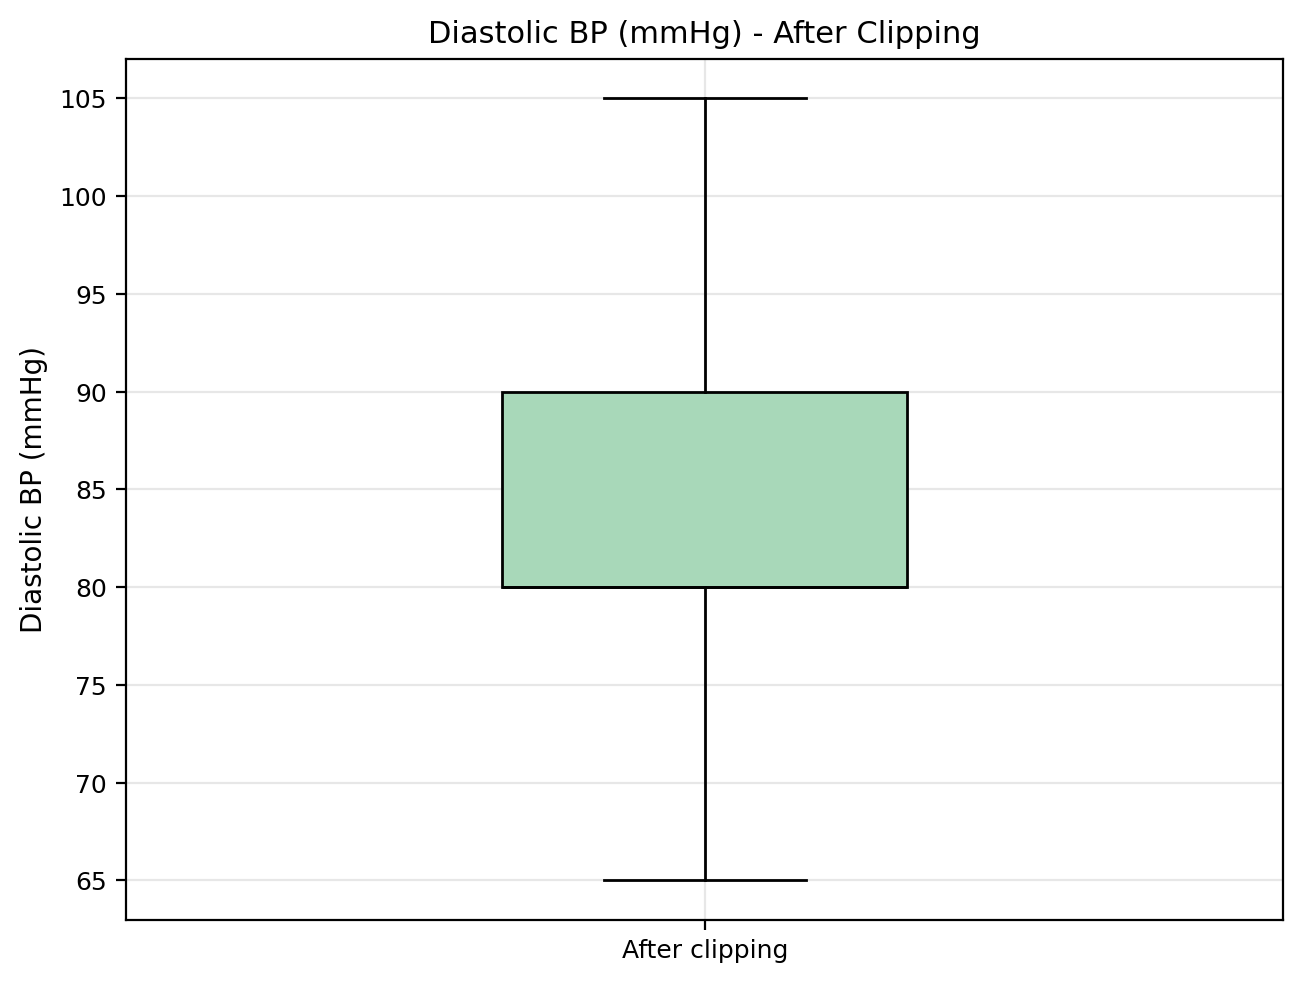

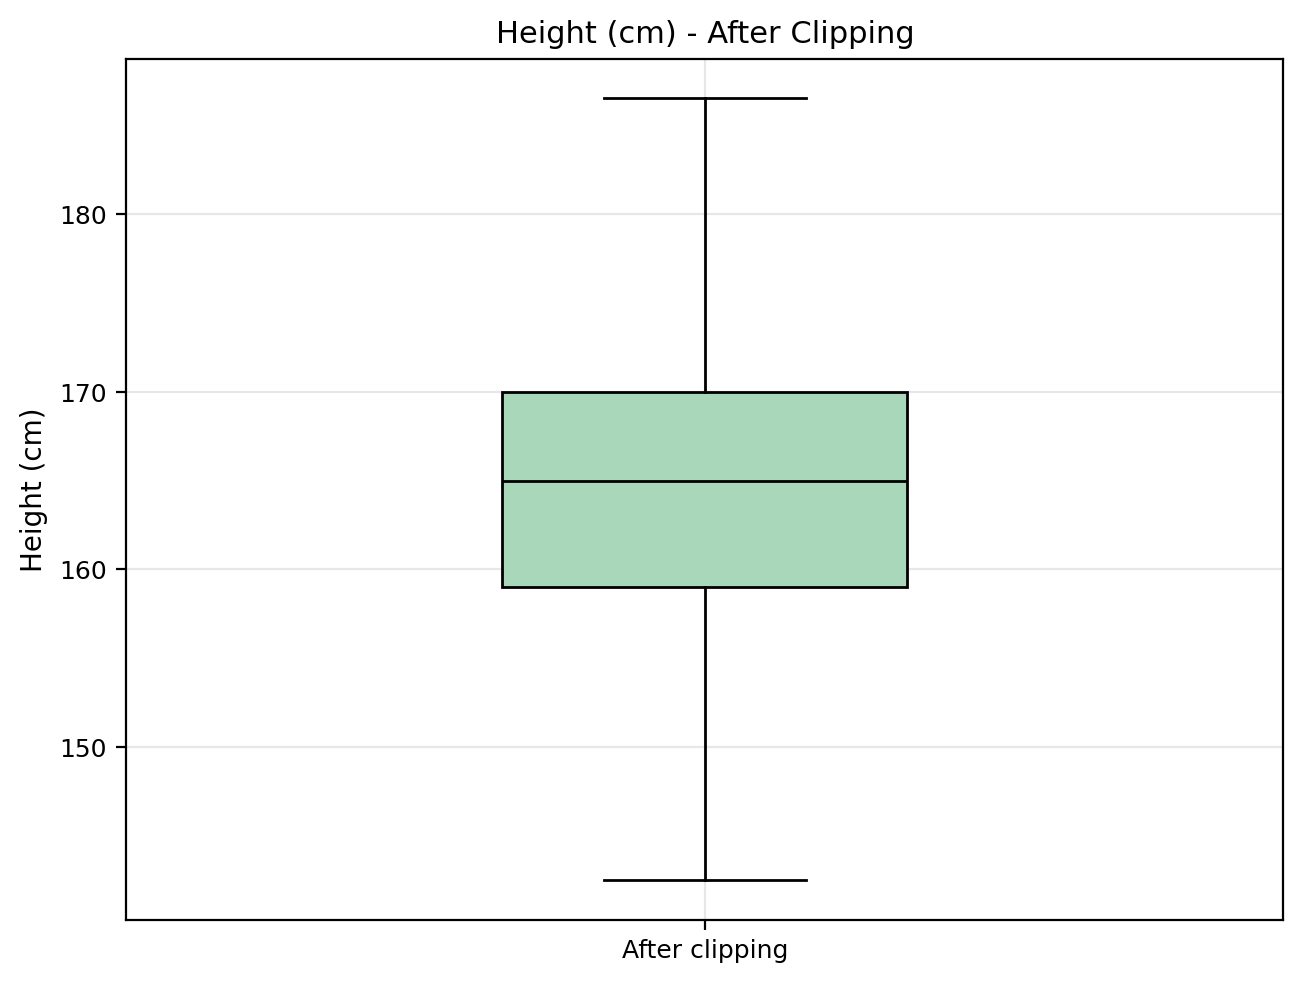

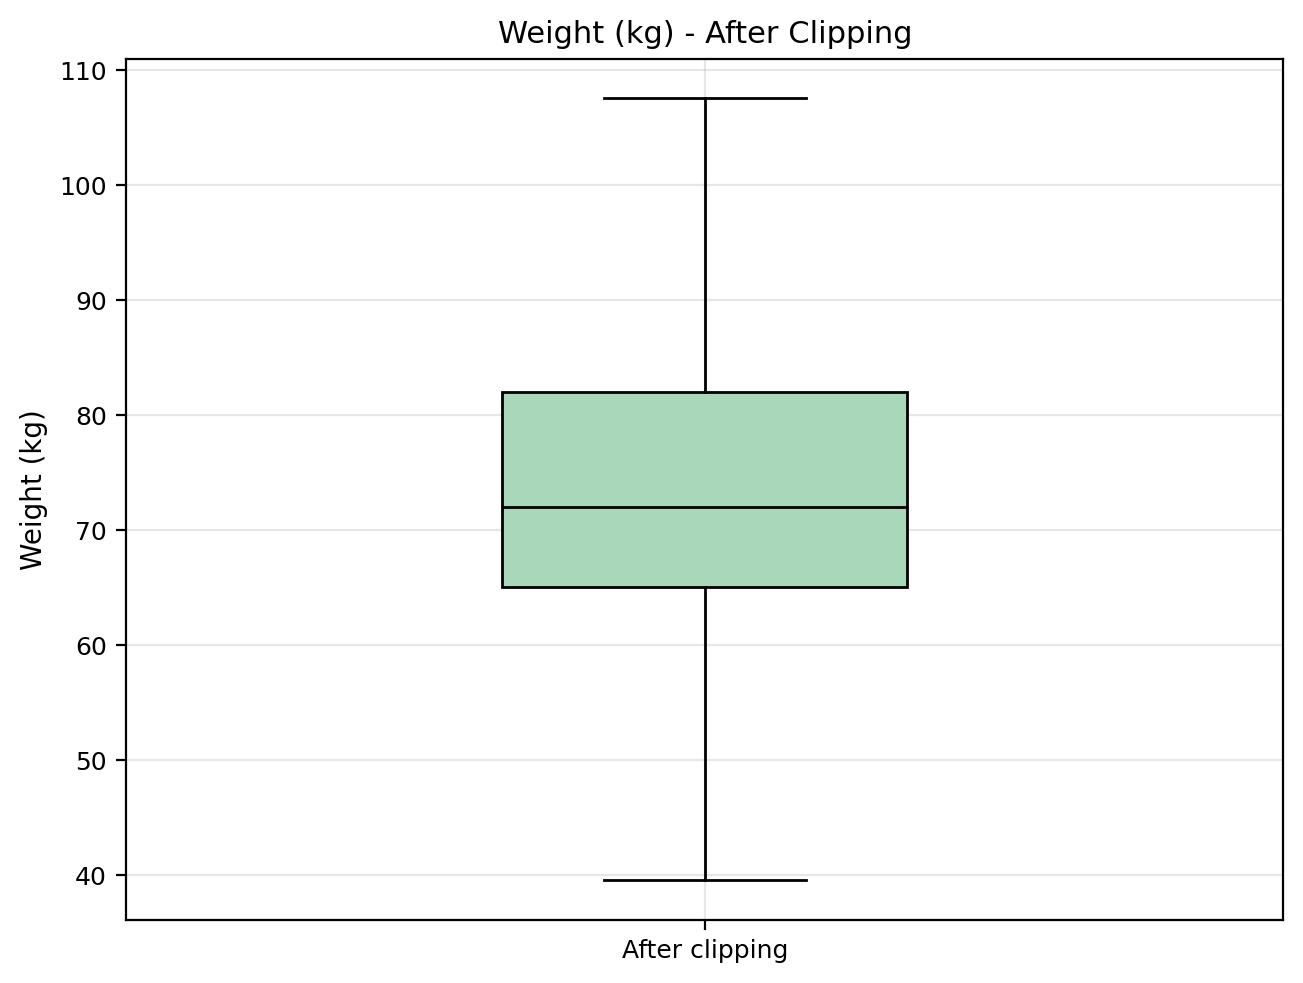

In [15]:
for col, lab in LABELS.items():
    fig, ax = plt.subplots()
    src = X_train[col] * 100 if col == 'height' else X_train[col]
    ax.boxplot(src, patch_artist=True, widths=0.35,
               boxprops={'facecolor': '#A8D8B9', 'edgecolor': 'black'},
               medianprops={'color': 'black'},
               flierprops={'markersize': 2.5, 'alpha': 0.4})
    ax.set_ylabel(lab)
    ax.set_xticks([1]); ax.set_xticklabels(['After clipping'])
    ax.set_title(f'{lab} - After Clipping')
    save(fig, f'fig_box_after_{col}')

### 6.4 Feature correlation

Pearson correlation between the final features and the target, computed on the training partition.

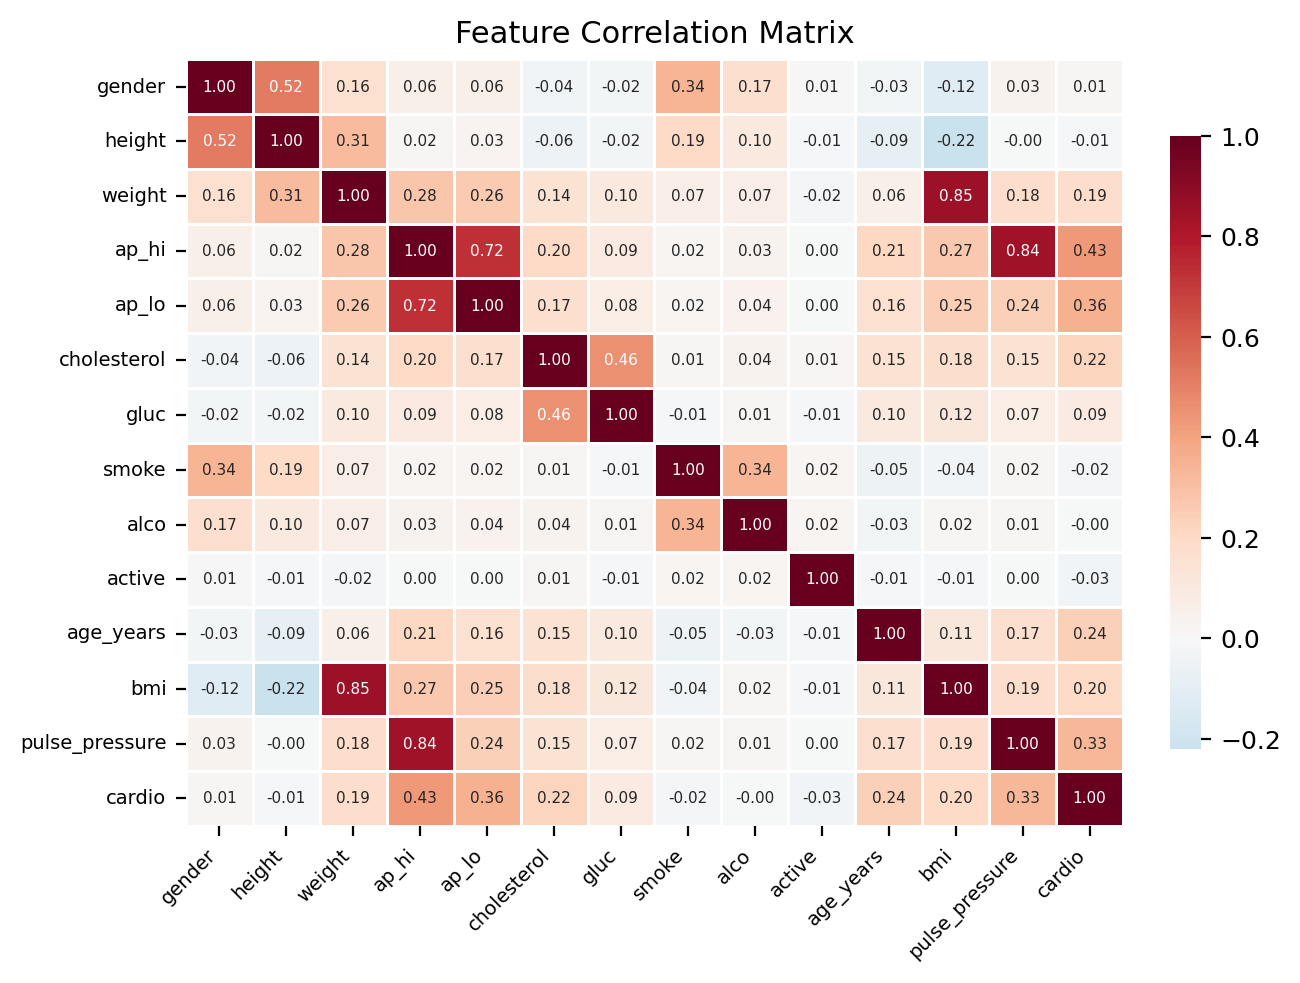

In [16]:
fig, ax = plt.subplots()
corr = X_train.assign(cardio=y_train.values).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 5.5}, ax=ax)
ax.set_title('Feature Correlation Matrix')
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
save(fig, 'fig_correlation_matrix')

### 6.5 Standardisation

In [17]:
scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)
X_train_s.describe().round(3).loc[['mean', 'std']]

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,pulse_pressure
mean,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. Classifiers

Four tree-based ensembles are trained on the same partition. Hyperparameters were selected by
3-fold cross-validation on the training set.

In [18]:
MODELS = {
    'LightGBM':          LGBMClassifier(n_estimators=100, random_state=42,
                                        verbose=-1, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                       random_state=42, eval_metric='logloss',
                                       verbosity=0, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=400, max_depth=14,
                                                min_samples_leaf=10, random_state=42,
                                                n_jobs=-1),
}

pred, proba = {}, {}
for name, m in MODELS.items():
    m.fit(X_train_s, y_train)
    pred[name]  = m.predict(X_test_s)
    proba[name] = m.predict_proba(X_test_s)[:, 1]
    print(f'{name:<18} trained')

LightGBM           trained


XGBoost            trained


Gradient Boosting  trained


Random Forest      trained


## 8. Results

Performance on the held-out test set, followed by 5-fold stratified cross-validation on the
training set to show variation across splits.

In [19]:
perf = pd.DataFrame({
    n: [accuracy_score(y_test, pred[n]), precision_score(y_test, pred[n]),
        recall_score(y_test, pred[n]),   f1_score(y_test, pred[n]),
        roc_auc_score(y_test, proba[n])] for n in MODELS
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']).T

print('Test-set performance')
print(perf.round(4).to_string())
print()
for metric in perf.columns:
    print(f'Best {metric:<10}: {perf[metric].idxmax():<18} ({perf[metric].max():.4f})')

Test-set performance
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
LightGBM             0.7357     0.7548  0.6979    0.7252   0.8046
XGBoost              0.7358     0.7576  0.6931    0.7239   0.8057
Gradient Boosting    0.7370     0.7575  0.6969    0.7259   0.8046
Random Forest        0.7369     0.7606  0.6912    0.7242   0.8041

Best Accuracy  : Gradient Boosting  (0.7370)
Best Precision : Random Forest      (0.7606)
Best Recall    : LightGBM           (0.6979)
Best F1-Score  : Gradient Boosting  (0.7259)
Best ROC-AUC   : XGBoost            (0.8057)


### 8.1 Cross-validation

In [20]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows = {}
for name, m in MODELS.items():
    acc = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='f1',       n_jobs=-1)
    auc = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='roc_auc',  n_jobs=-1)
    rows[name] = [acc.mean(), acc.std(), f1.mean(), f1.std(), auc.mean(), auc.std()]

cv_df = pd.DataFrame(rows, index=['Acc mean', 'Acc std', 'F1 mean',
                                  'F1 std', 'AUC mean', 'AUC std']).T
print('5-fold stratified cross-validation on the training set')
print(cv_df.round(4).to_string())

5-fold stratified cross-validation on the training set
                   Acc mean  Acc std  F1 mean  F1 std  AUC mean  AUC std
LightGBM             0.7367   0.0030   0.7262  0.0040    0.8011   0.0030
XGBoost              0.7364   0.0032   0.7254  0.0040    0.8021   0.0030
Gradient Boosting    0.7349   0.0032   0.7245  0.0040    0.8017   0.0030
Random Forest        0.7356   0.0041   0.7238  0.0046    0.8007   0.0031


### 8.2 Confusion matrices

One figure per classifier.

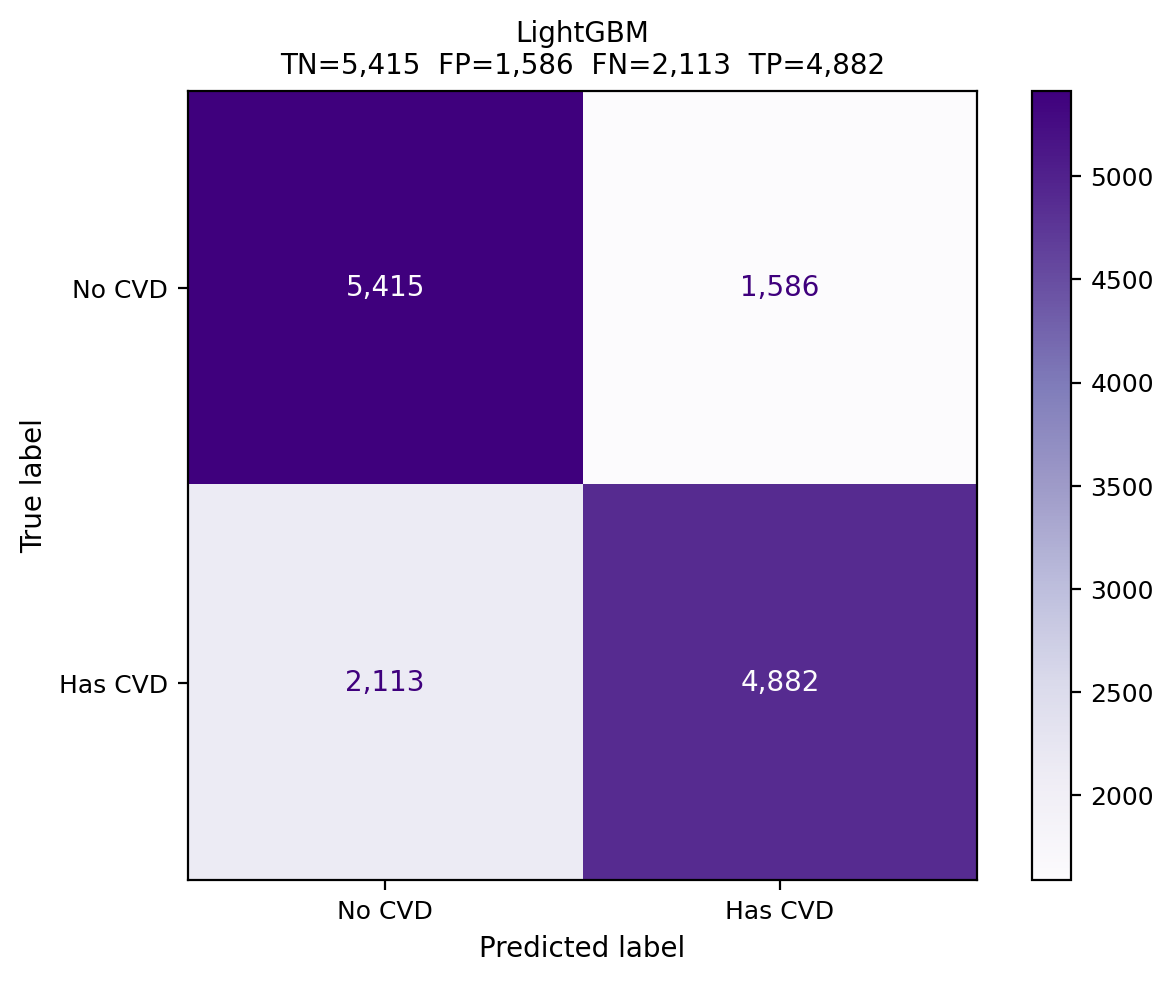

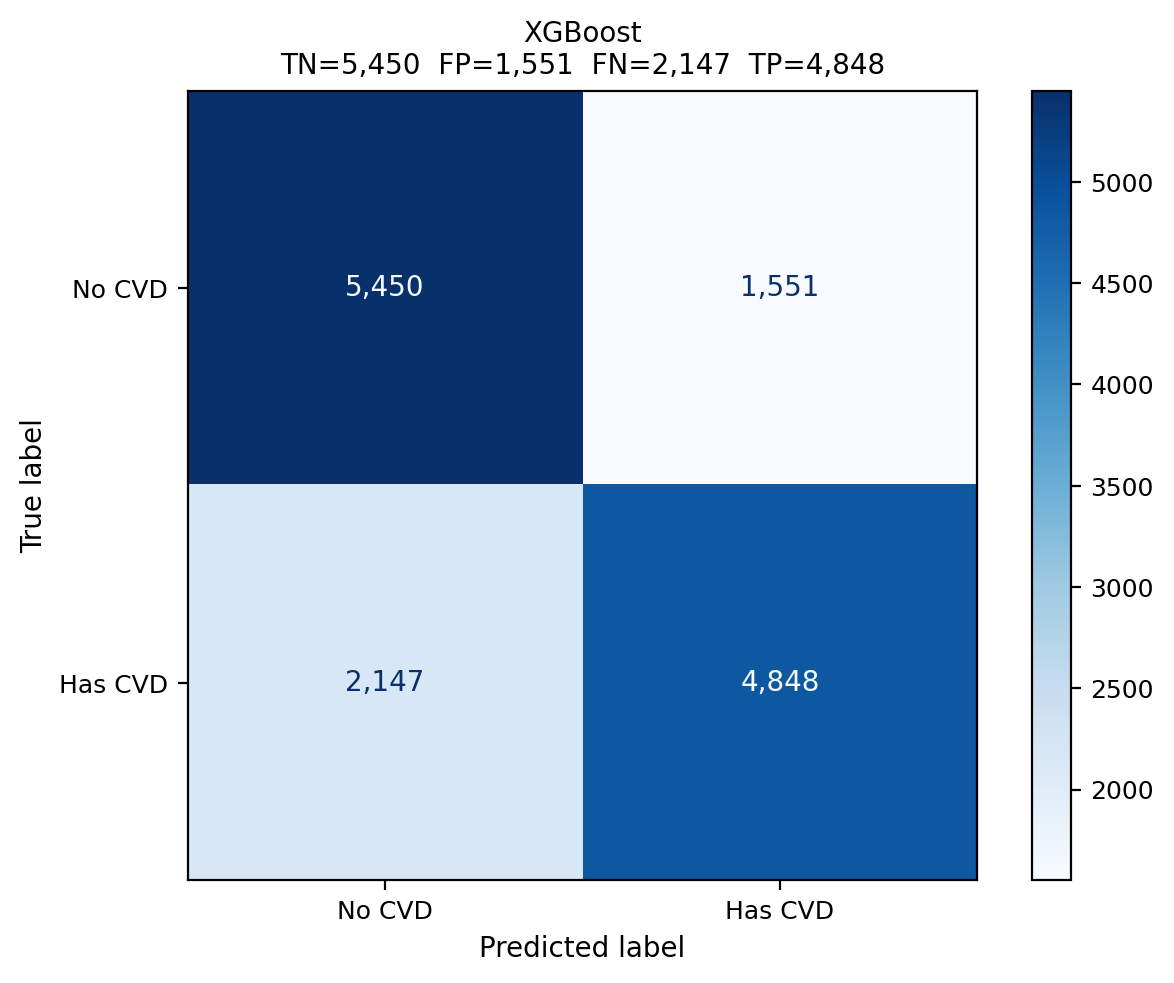

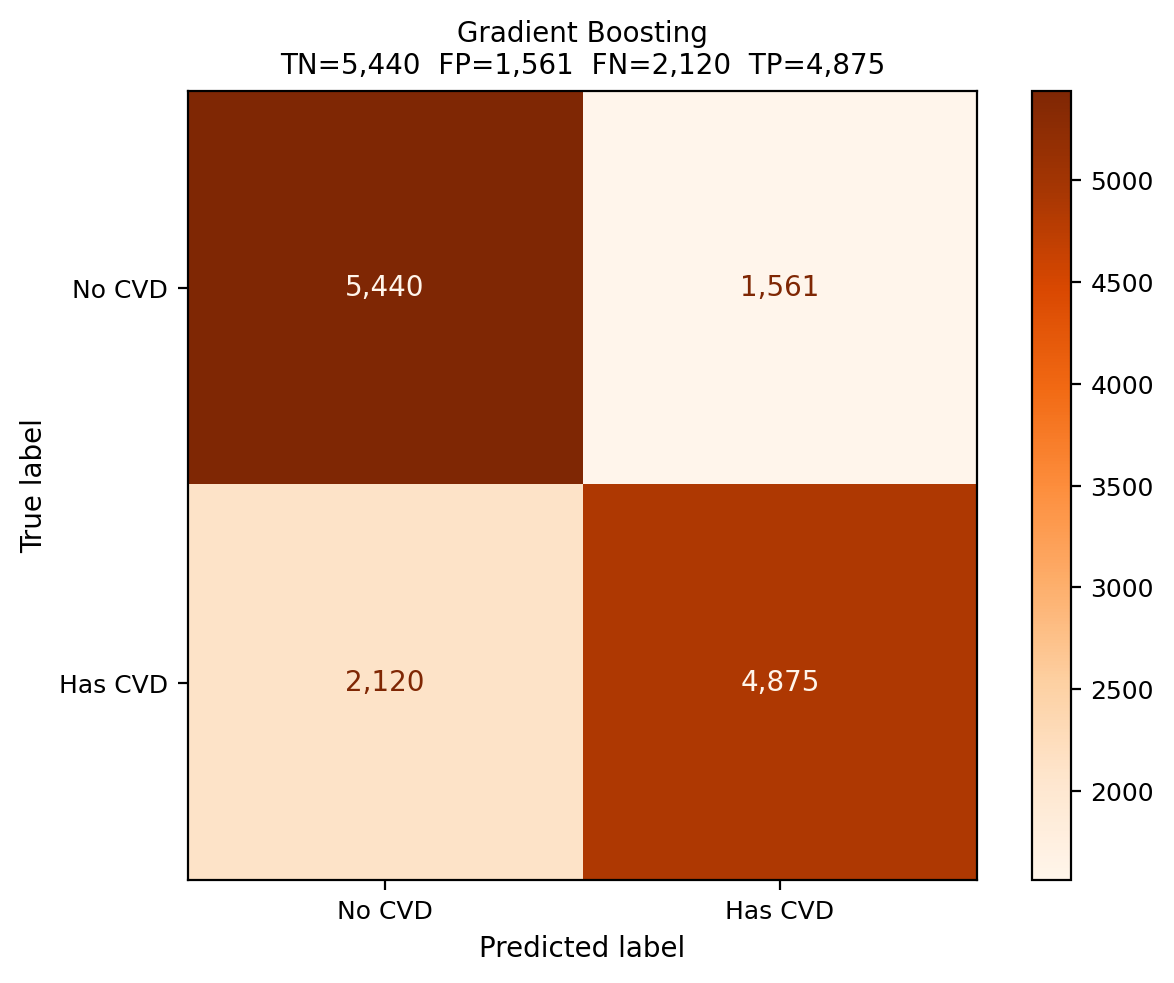

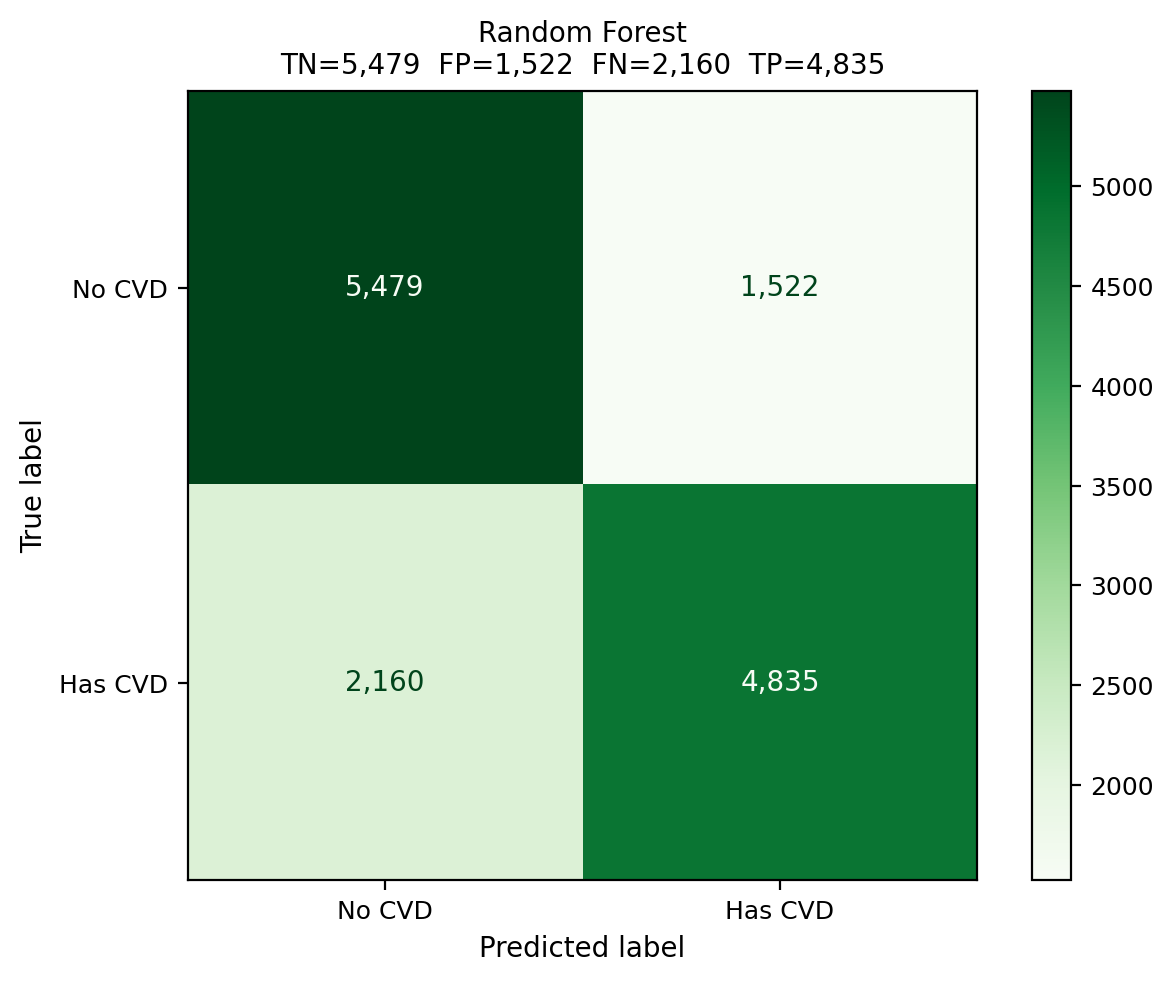

In [21]:
for name in MODELS:
    fig, ax = plt.subplots()
    cm = confusion_matrix(y_test, pred[name])
    ConfusionMatrixDisplay(cm, display_labels=['No CVD', 'Has CVD']).plot(
        cmap=CMAPS[name], ax=ax, colorbar=True, values_format=',d')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}', fontsize=10)
    ax.grid(False)
    save(fig, f'fig_cm_{name.lower().replace(" ", "_")}')

### 8.3 ROC curves

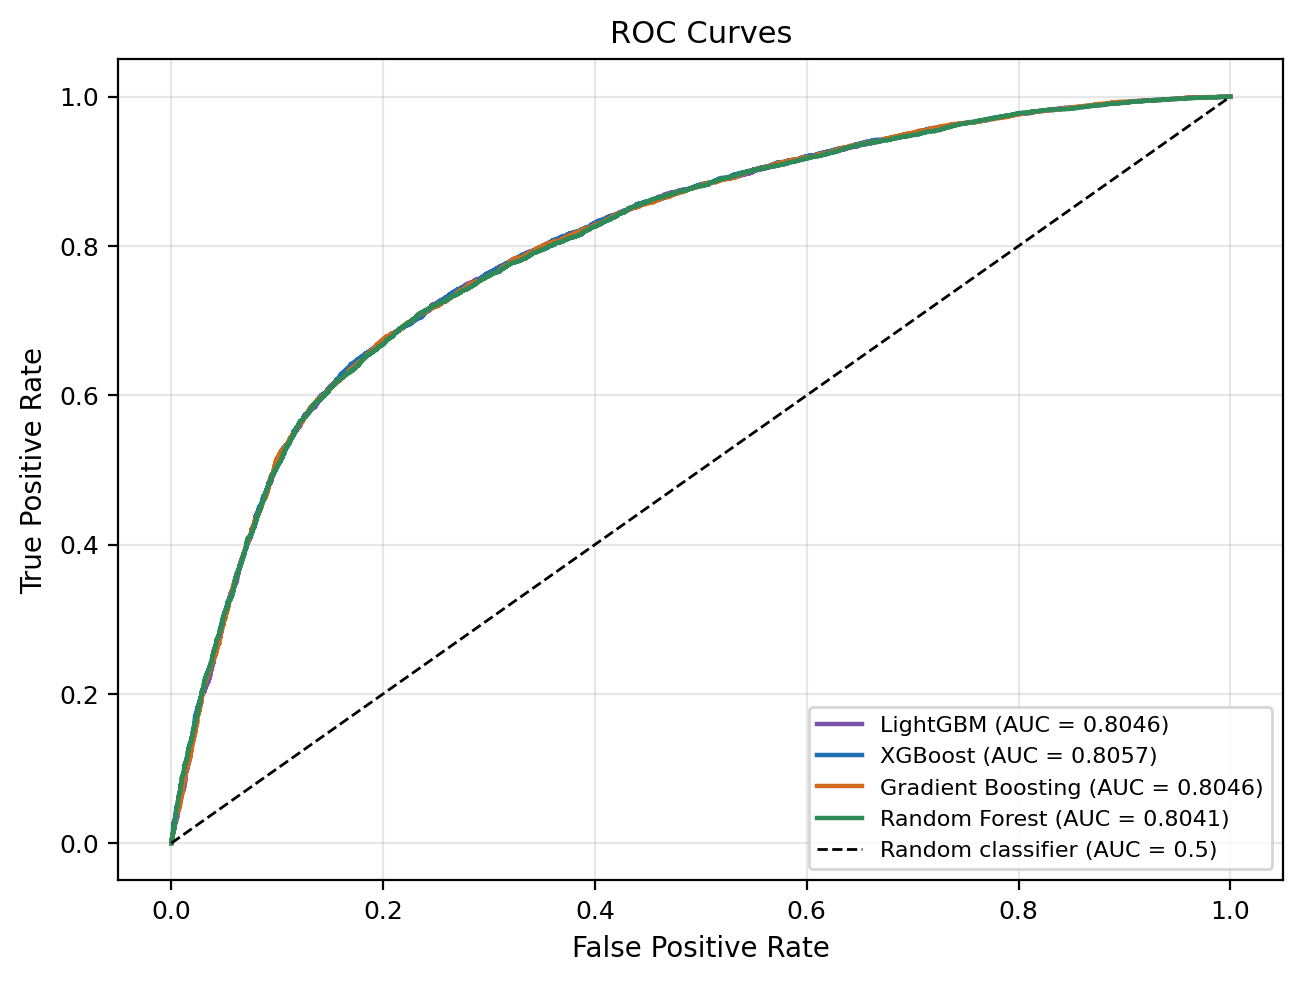

In [22]:
fig, ax = plt.subplots()
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax.plot(fpr, tpr, lw=1.6, color=PALETTE[name],
            label=f'{name} (AUC = {roc_auc_score(y_test, proba[name]):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=8)
save(fig, 'fig_roc_curves')

### 8.4 ROC-AUC by model

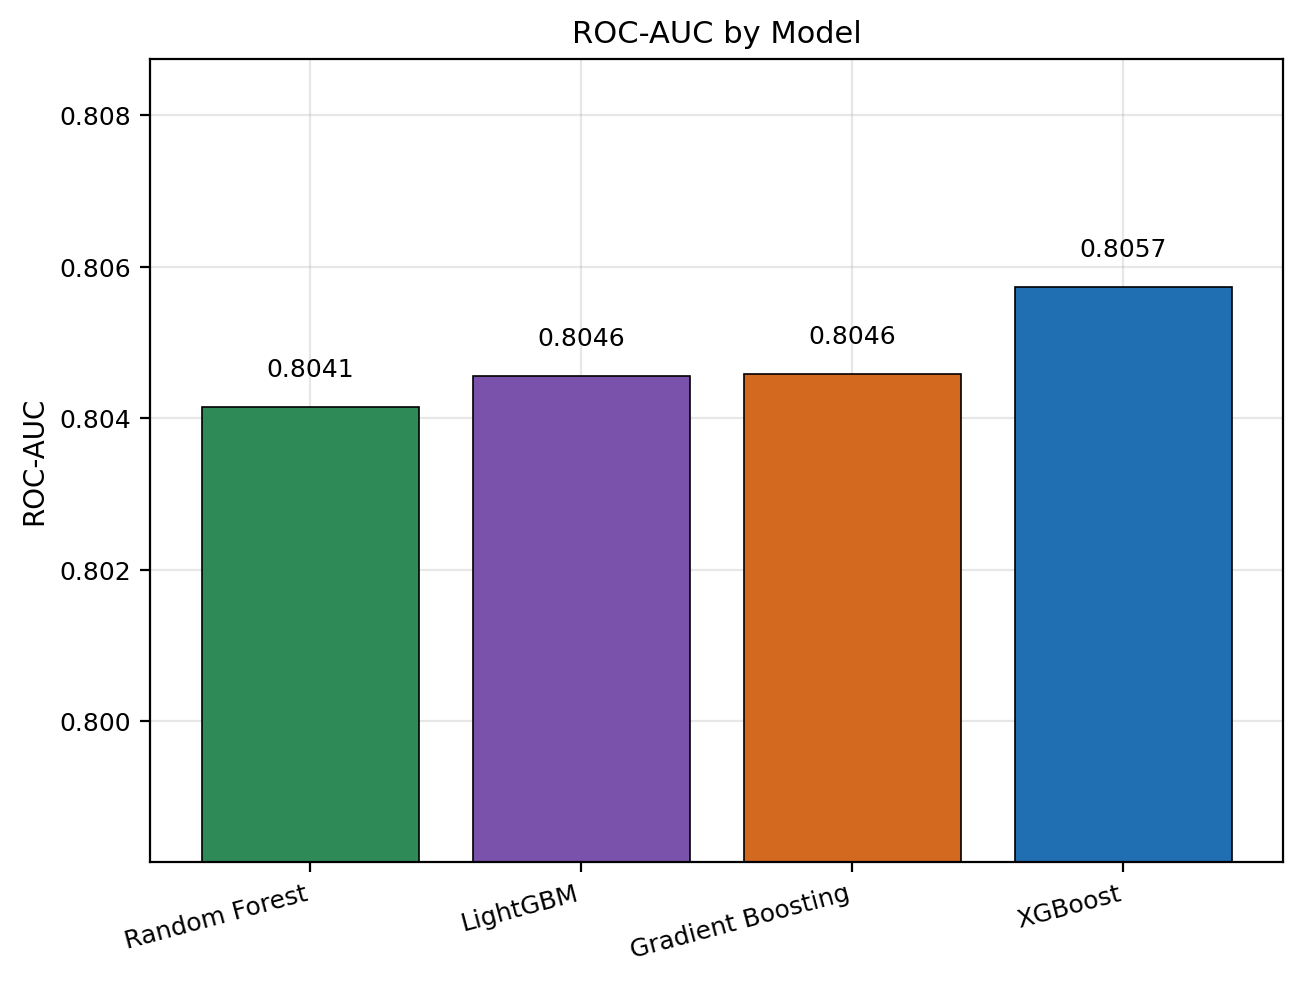

In [23]:
fig, ax = plt.subplots()
aucs = perf['ROC-AUC'].sort_values()
ax.bar(range(len(aucs)), aucs.values, color=[PALETTE[n] for n in aucs.index],
       edgecolor='black', linewidth=0.6)
for i, v in enumerate(aucs.values):
    ax.text(i, v + 0.0004, f'{v:.4f}', ha='center', fontsize=9)
ax.set_xticks(range(len(aucs)))
ax.set_xticklabels(aucs.index, rotation=15, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(aucs.min() - 0.006, aucs.max() + 0.003)
ax.set_title('ROC-AUC by Model')
save(fig, 'fig_auc_comparison')

### 8.5 Precision-recall curves

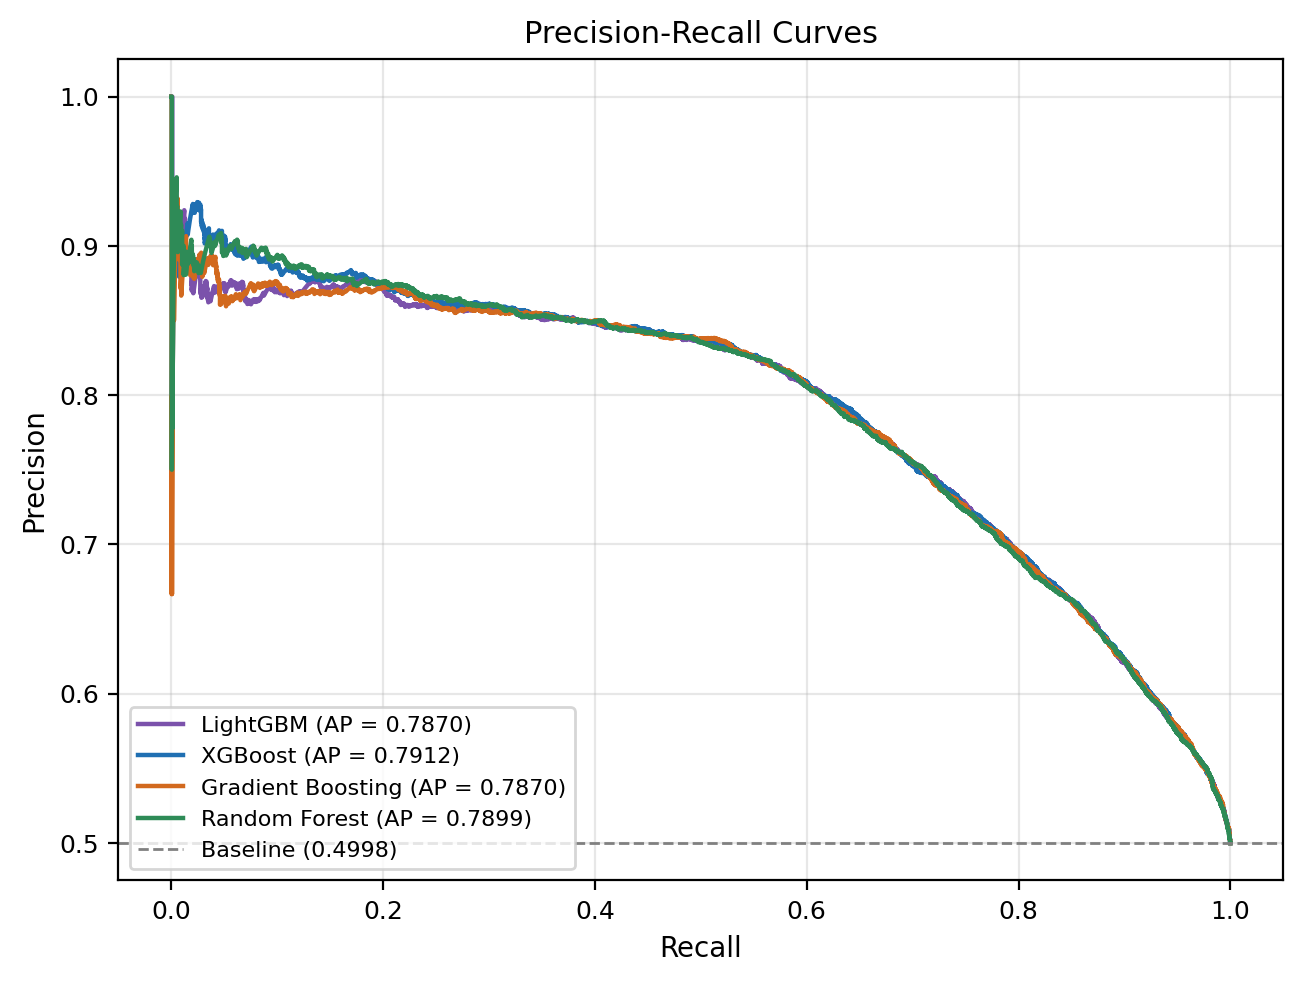

In [24]:
fig, ax = plt.subplots()
for name in MODELS:
    p_, r_, _ = precision_recall_curve(y_test, proba[name])
    ax.plot(r_, p_, lw=1.6, color=PALETTE[name],
            label=f'{name} (AP = {average_precision_score(y_test, proba[name]):.4f})')
ax.axhline(y_test.mean(), color='gray', ls='--', lw=1,
           label=f'Baseline ({y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='lower left', fontsize=8)
save(fig, 'fig_pr_curves')

### 8.6 Metric comparison

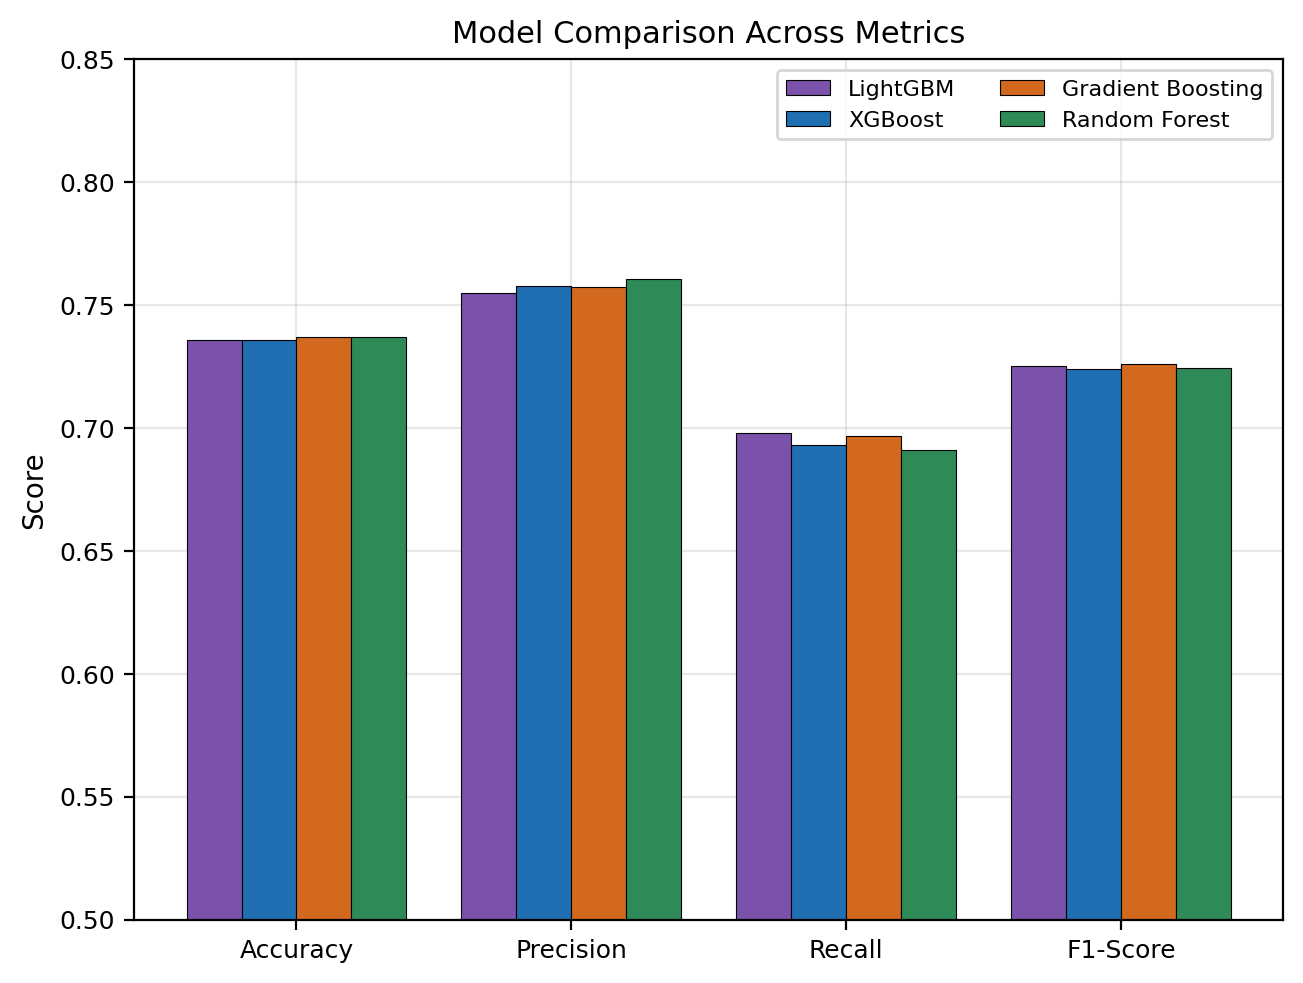

In [25]:
fig, ax = plt.subplots()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
xpos, w = np.arange(len(metrics)), 0.2
for i, name in enumerate(MODELS):
    ax.bar(xpos + (i - 1.5) * w, perf.loc[name, metrics].values, w,
           label=name, color=PALETTE[name], edgecolor='black', linewidth=0.4)
ax.set_xticks(xpos); ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 0.85)
ax.set_title('Model Comparison Across Metrics')
ax.legend(fontsize=8, ncol=2)
save(fig, 'fig_metric_comparison')

## 9. Feature importance

Importance scores are normalised to sum to 1 within each model, then averaged to give a
consensus ranking.

In [26]:
imp = pd.DataFrame({n: MODELS[n].feature_importances_ / MODELS[n].feature_importances_.sum()
                    for n in MODELS}, index=FEATURES)
imp['Mean'] = imp.mean(axis=1)
imp = imp.sort_values('Mean', ascending=False)
print(imp.round(4).to_string())

                LightGBM  XGBoost  Gradient Boosting  Random Forest    Mean
ap_hi             0.0873   0.6588             0.7317         0.3039  0.4454
age_years         0.2350   0.0591             0.1278         0.1419  0.1410
cholesterol       0.0547   0.1076             0.0731         0.0747  0.0775
ap_lo             0.0490   0.0383             0.0204         0.1589  0.0667
bmi               0.1690   0.0147             0.0165         0.0653  0.0664
pulse_pressure    0.0730   0.0118             0.0066         0.1430  0.0586
weight            0.1190   0.0149             0.0078         0.0470  0.0472
height            0.1023   0.0081             0.0028         0.0331  0.0366
gluc              0.0350   0.0159             0.0043         0.0117  0.0167
active            0.0250   0.0276             0.0052         0.0082  0.0165
smoke             0.0153   0.0199             0.0022         0.0040  0.0104
gender            0.0233   0.0109             0.0005         0.0059  0.0102
alco        

### 9.1 Mean importance

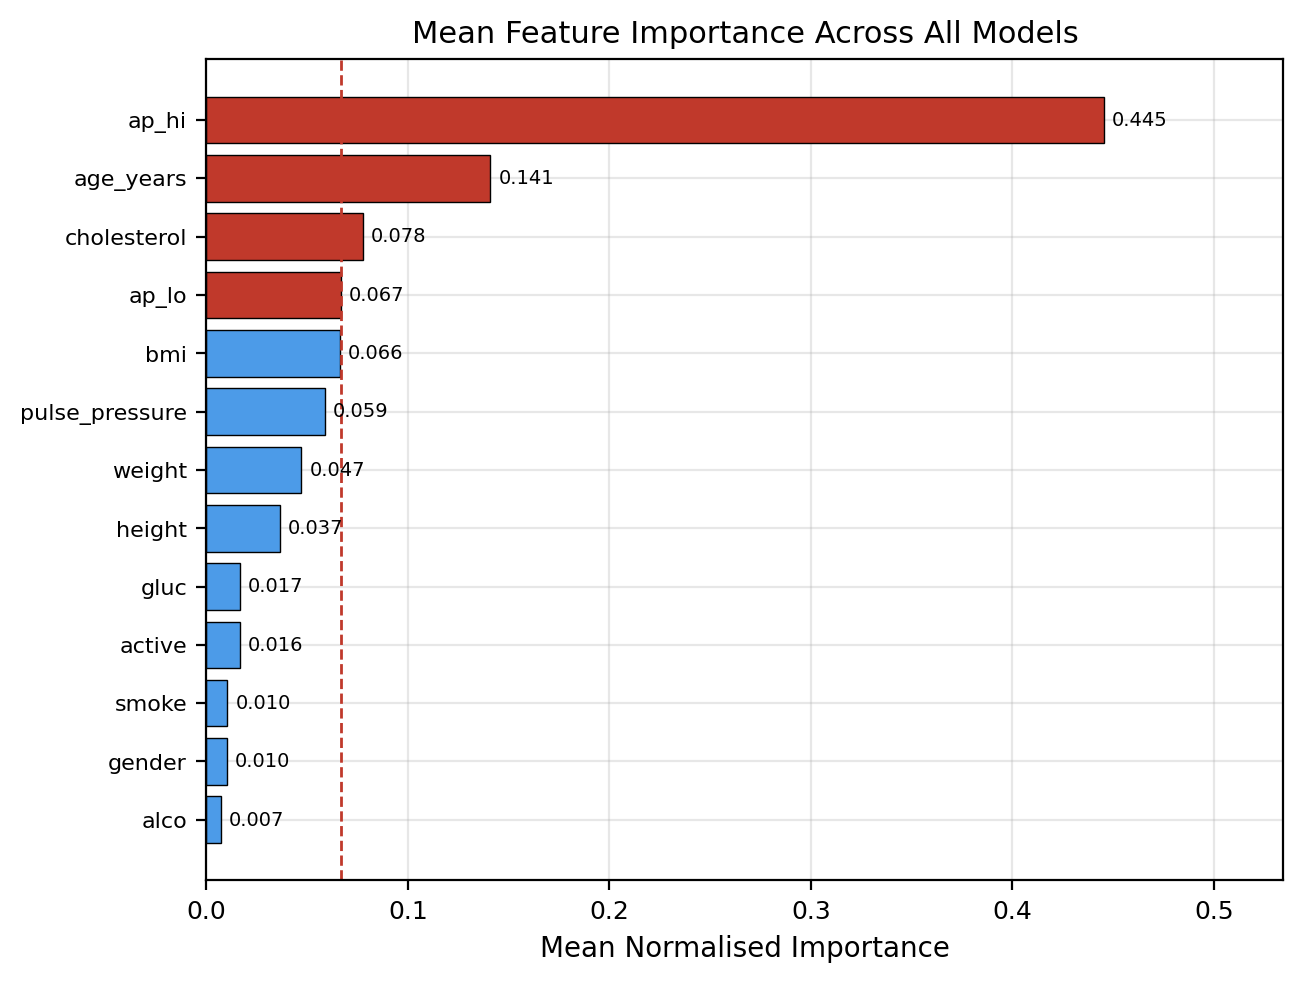

In [27]:
fig, ax = plt.subplots()
top = imp['Mean'].sort_values()
thr = imp['Mean'].quantile(0.75)
ax.barh(range(len(top)), top.values, edgecolor='black', linewidth=0.5,
        color=['#C0392B' if v >= thr else '#4C9BE8' for v in top.values])
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(thr, color='#C0392B', ls='--', lw=1)
for i, v in enumerate(top.values):
    ax.text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=7)
ax.set_xlabel('Mean Normalised Importance')
ax.set_xlim(0, top.max() * 1.20)
ax.set_title('Mean Feature Importance Across All Models')
save(fig, 'fig_importance_mean')

### 9.2 Importance per model

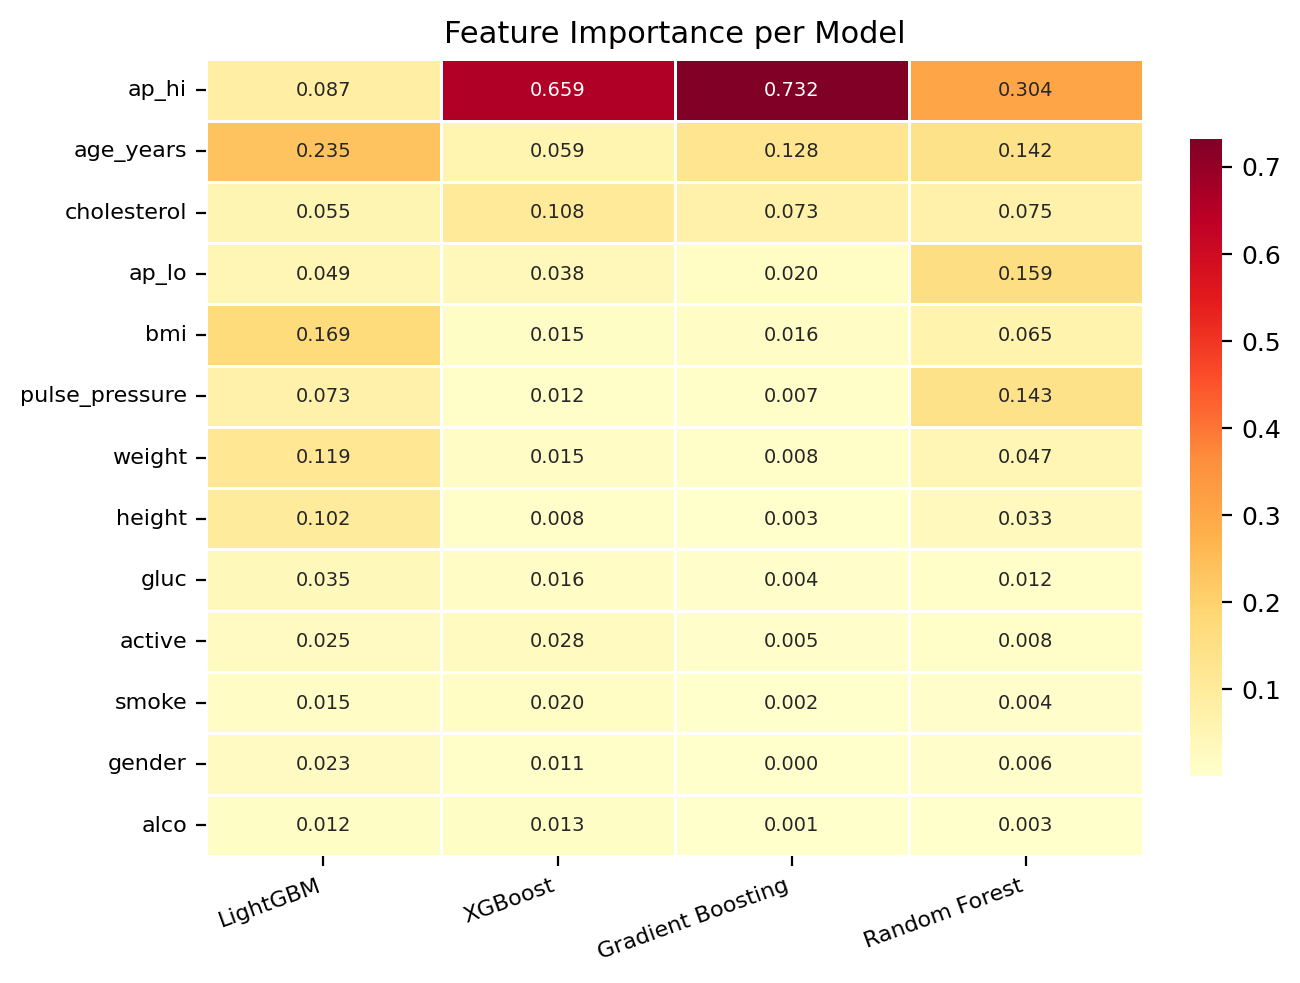


23 figures written to figures/


In [28]:
fig, ax = plt.subplots()
sns.heatmap(imp[list(MODELS)], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Importance per Model')
ax.set_ylabel('')
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
save(fig, 'fig_importance_heatmap')
print(f'\n{len(os.listdir(OUT))} figures written to {OUT}/')